In [1]:
%matplotlib inline
%config InlineBackend.figure_formats={'png','retina'}
import numpy as np
np.set_printoptions(precision=2, suppress=True)
import time
import os
import itertools
import pandas as pd
from tqdm import tqdm

from scipy.stats import zscore, pearsonr
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error

from utils import plot_functions
from utils import training_utils

from scipy.stats import t
import shap
import matplotlib.pyplot as plt

# import importlib
# importlib.reload(plot_functions)


COLOR_DICT = {
    '2016_Furukawa': '#4B73B0',
    '2020_Furukawa': '#DD8553',
    '2021_Kelly': '#55A868',
    '2022_Bhardwaj': '#C54F53',
    '2D': '#3F3E3C',
    '3D': '#F2B53B',
    'PS3D': '#F18274',
    'diffPS3D': '#D83F37'
}


### Data import
+ 735 dims
+ 2D:   188type 188dims
+ 3D:    49type  49dims
+ PS3D:  82type 246dims
+ ∆PS3D: 84type 252dims

In [2]:
# NOTE: Exclude those with AlogP > 4
unuse_name = ['D10.21', 'D10.22', 'D10.23', 'D8.21']

df = pd.read_csv('data/y.csv', index_col=0).drop(unuse_name, axis=0).reset_index(drop=True).iloc[:252] 
y = df['PAMPA'].to_numpy()
df_desc = pd.read_csv('data/descriptors.csv', index_col=0).drop(unuse_name, axis=0).reset_index(drop=True).iloc[:252] 

# apply Z-score
X = df_desc.apply(zscore)
print(X.isna().sum().sum())
print(X.shape)
print(y.shape)

0
(252, 735)
(252,)


### Determining the index for 5-fold cv
+ If indexes are already recorded, read them from the file.

In [3]:
cv = 5
kf = KFold(n_splits=cv, random_state=2024, shuffle=True)

save_dir = 'data/eval_index'
os.makedirs(save_dir, exist_ok=True)

train_index_cv, test_index_cv = {}, {}

for i, (train_index, test_index) in enumerate(kf.split(df)):
    train_path = f'{save_dir}/train_index_cv{i}.npy'
    test_path  = f'{save_dir}/test_index_cv{i}.npy'

    if os.path.exists(train_path) and os.path.exists(test_path):
        train_index_cv[i] = np.load(train_path)
        test_index_cv[i]  = np.load(test_path)
    else:
        train_index_cv[i] = train_index
        test_index_cv[i]  = test_index
        np.save(train_path, train_index)
        np.save(test_path, test_index)

### Determining the threshold for selecting descriptors based on RF
+ please skip this process when the threshols are already determined

In [10]:
## NOTE: There are no descriptors with std of 0.
#th_list = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
## for RF model
#th_cv_seeds = [2440, 1984, 466, 4093, 7]

#MAE_list = []

#for th in th_list:
#    # delete features
#    features_delete = training_utils.delete_similarity(X, y, th)
#    X_now = X.drop(features_delete, axis=1)
#    now_features = X_now.columns.to_list()
#    X_now = X_now.to_numpy()

#    MAE_th = []
#    for i in range(cv):
#        # default: n_estimators=100
#        RF = RandomForestRegressor(n_estimators=100, random_state=th_cv_seeds[i], n_jobs=12)
#        RF.fit(X_now[train_index_cv[i]], y[train_index_cv[i]])
#        y_pred = RF.predict(X_now[test_index_cv[i]])
#        MAE = mean_absolute_error(y[test_index_cv[i]], y_pred)
#        MAE_th.append(MAE)

#    print(f'th: {th:.2f}, now features: {len(now_features):3}, MAE: {np.mean(MAE_th):.3f} +- {np.std(MAE_th):.3f}')
#    pd.DataFrame(now_features, columns=['feature']).to_csv(f'data/use_features_th{th}.csv', index=False)

#    MAE_list.append(MAE_th)

th: 0.40, now features:  31, MAE: 0.507 +- 0.032
th: 0.45, now features:  38, MAE: 0.492 +- 0.026
th: 0.50, now features:  49, MAE: 0.504 +- 0.027
th: 0.55, now features:  64, MAE: 0.503 +- 0.024
th: 0.60, now features:  94, MAE: 0.482 +- 0.052
th: 0.65, now features: 112, MAE: 0.487 +- 0.053
th: 0.70, now features: 136, MAE: 0.484 +- 0.053
th: 0.75, now features: 173, MAE: 0.483 +- 0.047
th: 0.80, now features: 221, MAE: 0.480 +- 0.052
th: 0.85, now features: 269, MAE: 0.487 +- 0.054
th: 0.90, now features: 328, MAE: 0.480 +- 0.047
th: 0.95, now features: 425, MAE: 0.486 +- 0.050


In [4]:
th_list = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
MAE_list = np.array([0.507, 0.492, 0.504, 0.503, 0.482, 0.487, 0.484, 0.483, 0.480, 0.487, 0.480, 0.486])
std_list = np.array([0.032, 0.026, 0.027, 0.024, 0.052, 0.053, 0.053, 0.047, 0.052, 0.054, 0.047, 0.050])
feature_nums = [31, 38, 49, 64, 94, 112, 136, 173, 221, 269, 328, 425]

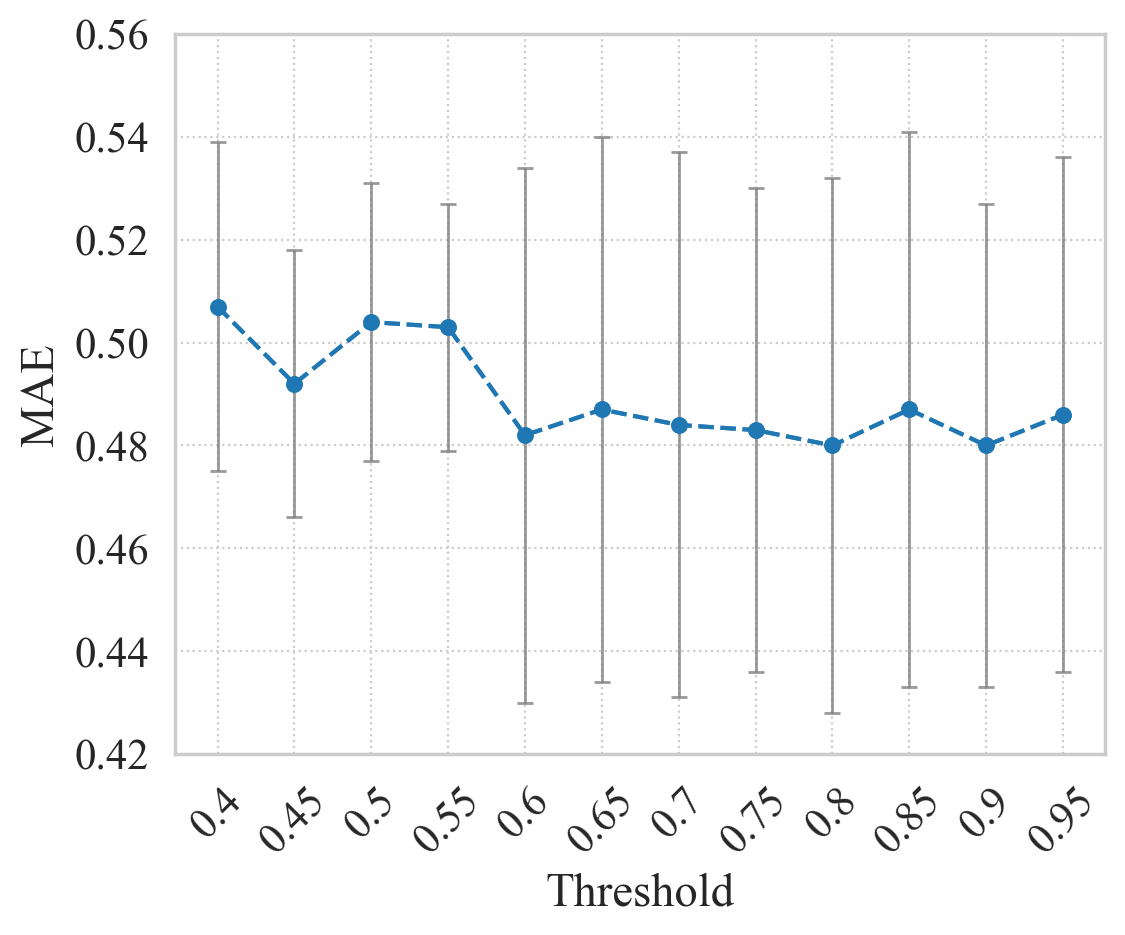

In [11]:
import importlib
importlib.reload(plot_functions)

yerr_style = {
    'alpha': 0.8,
    'elinewidth': 1,
    'ecolor': 'gray',
    'capsize': 3,
    'capthick': 1
}

plot_functions.plot_line([MAE_list], ['MAE'], 'Threshold', 'MAE',
                         color_list=['#1f77b4'], marker_list=['.'], linestyle_list=['--'],
                         yerr=[std_list], yerr_style=yerr_style,
                         x_ticks=[[_ for _ in range(len(th_list))], th_list],
                         ylim=[0.42, 0.56],
                         legend=False,
                         )

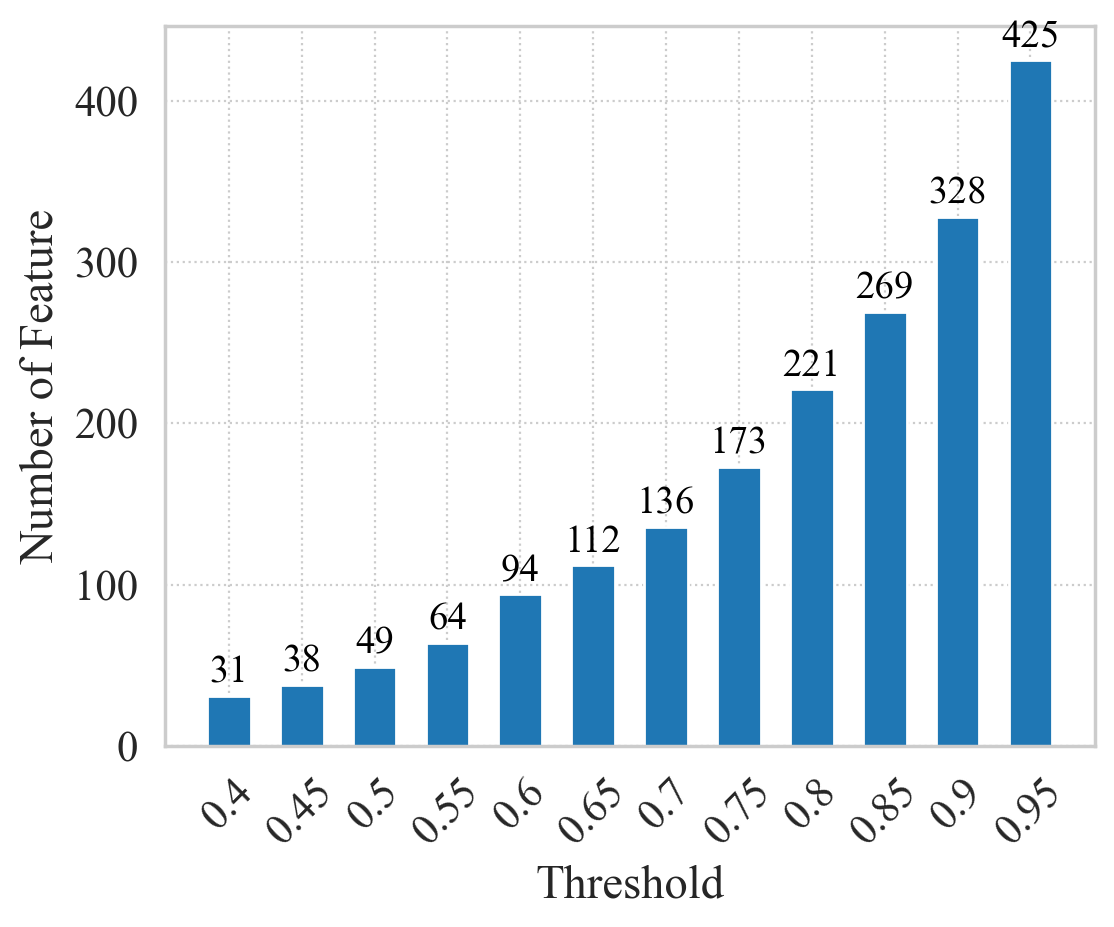

In [6]:
plot_functions.plot_bar([list(range(len(th_list)))], [np.array(feature_nums)], ['Feature Number'],
                        color_list=['#1f77b4'],
                        x_name='Threshold', y_name='Number of Feature', text=True,
                        x_ticks=[list(range(len(th_list))), th_list],
                        # y_lim=[0, 500],
                        rotation=45, legend=False)

### PCA analysis of descriptor space
+ The results of the PCA analysis will not be used in subsequent analyses.

In [7]:
th = 0.6

use_features = pd.read_csv(f'data/use_features_th{th}.csv')['feature'].to_list()
X = X[use_features] #already standardized

# fitting
pca = PCA(n_components=3)
pca.fit(X)
print(pca.explained_variance_ratio_)

# transformed data
transformed_data = pca.transform(X)
# Eigenvectors of each principal component
pca_components = pd.DataFrame(pca.components_, columns=X.columns, index=["PC{}".format(x + 1) for x in range(3)]).T

[0.09 0.08 0.05]


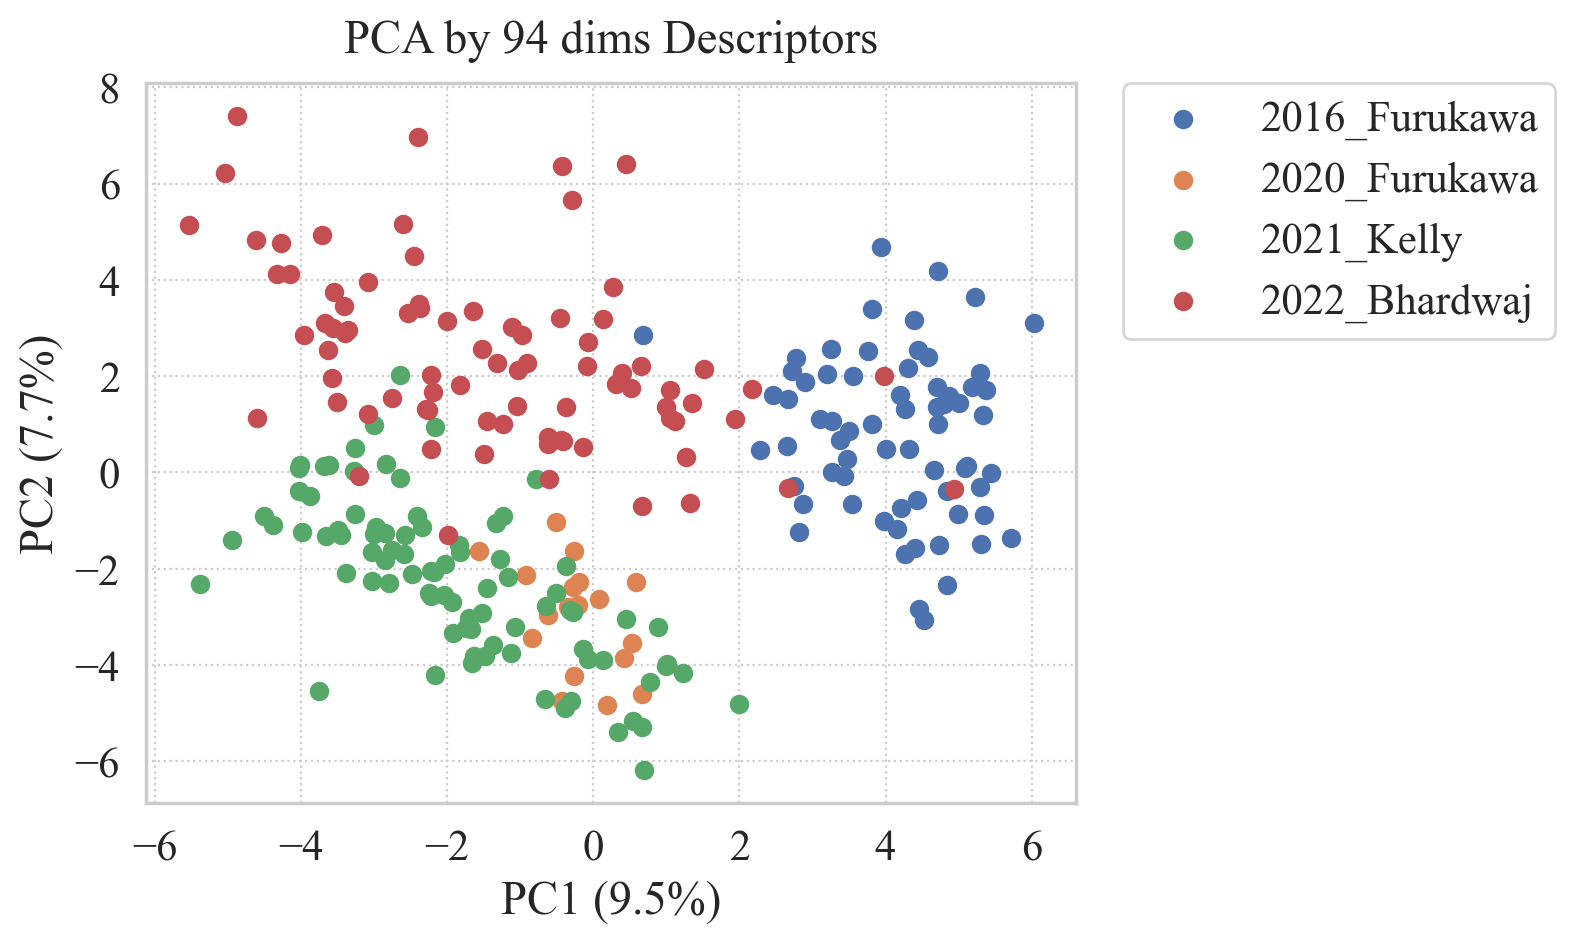

In [8]:
set_name = ['2016_Furukawa', '2020_Furukawa', '2021_Kelly', '2022_Bhardwaj']
title = f'PCA by {len(use_features)} dims Descriptors'

plot_functions.plot_PCA_space_all_sets(
    pca,
    [transformed_data[df[df['Set']==now_set].index.to_list()] for now_set in set_name],
    set_name,
    '',
    title=title,
    # color_list=['#7CB4EC', '#AFE9FF', '#9FE5C2'][:1],
    # alpha_list=[1],
    legend_outside=True,
    save_fig=False,
    )

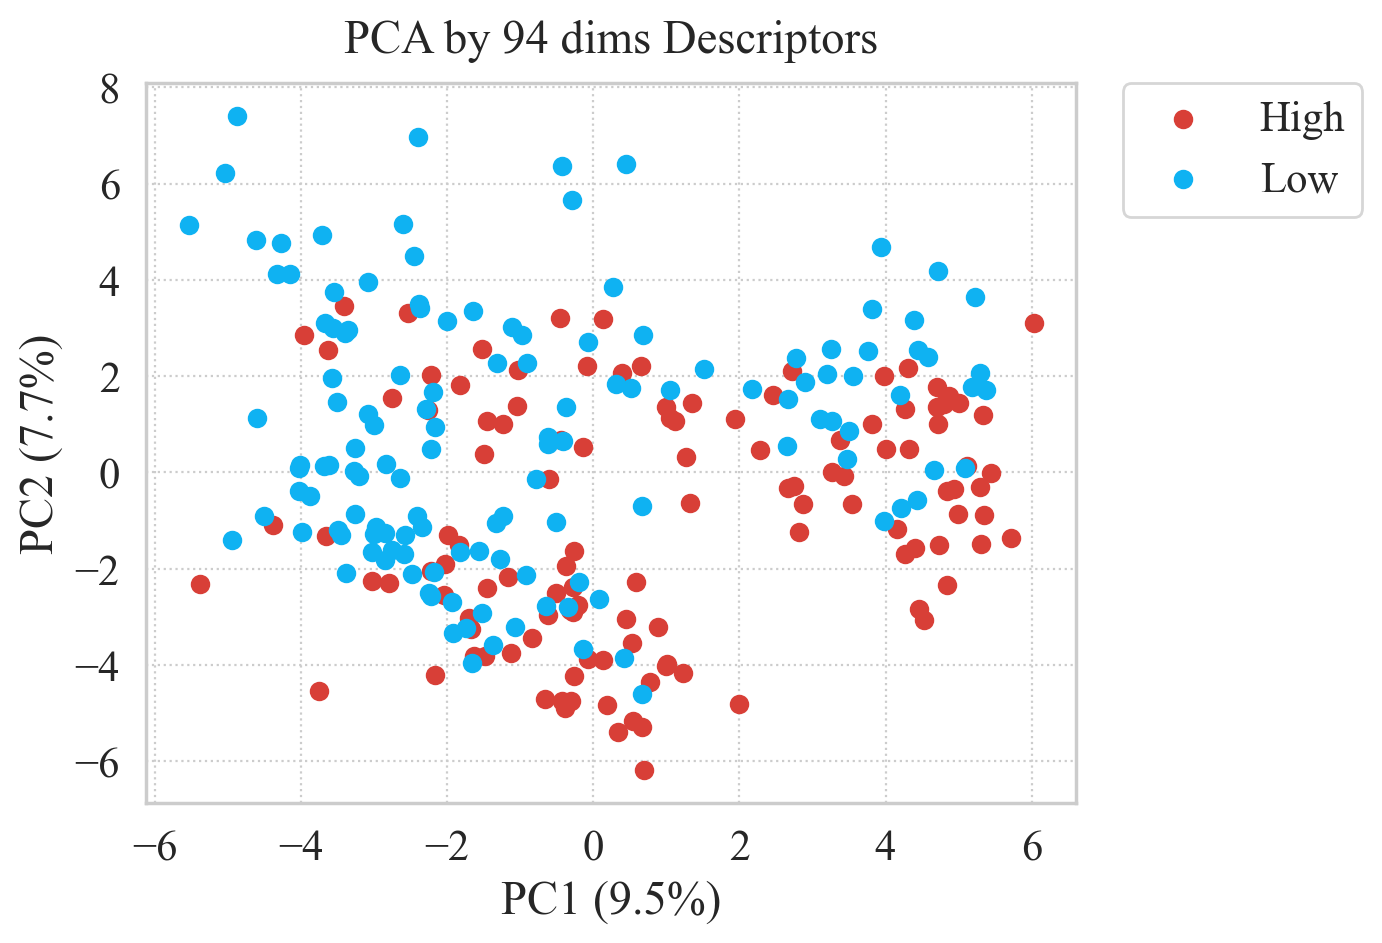

In [9]:
title = f'PCA by {len(use_features)} dims Descriptors'

plot_functions.plot_PCA_space_all_sets(
    pca,
    [transformed_data[df[df['PAMPA']>=-6].index.to_list()], transformed_data[df[df['PAMPA']<-6].index.to_list()]],
    ['High', 'Low'],
    '',
    title=title,
    color_list=['#D83F37', '#0FB2F2'],
    alpha_list=[1, 1],
    legend_outside=True,
    save_fig=False,
    )

In [10]:
pca_components.sort_values('PC1', ascending=False)

,PC1,PC2,PC3
dih_emd_sur_wat,0.190598,0.054761,-0.089661
E_sol_mem,0.185371,-0.149581,0.062979
vsurf_IW8_wat,0.181138,-0.109500,-0.047053
vsurf_HL2_mem - vsurf_HL2_wat,0.163684,-0.092489,0.027945
vsurf_EDmin1_sur,0.147809,-0.083186,-0.109047
...,...,...,...
vsurf_IW8_mem - vsurf_IW8_wat,-0.162133,0.032654,0.044096
in_hbond_mem - in_hbond_wat,-0.172974,-0.048994,0.246754
E_sol_mem - E_sol_wat,-0.207875,-0.029647,-0.068051
vsurf_W8_wat,-0.259281,0.125904,-0.075760


In [11]:
pca_components.sort_values('PC2', ascending=False)

,PC1,PC2,PC3
BCUT_PEOE_0,-0.004775,0.215560,-0.137163
density,-0.089719,0.196673,0.139907
vsurf_CW5_sur,-0.156936,0.171541,-0.086820
rsynth,0.115617,0.163717,0.173646
dE_vdw_mem - dE_vdw_sur,0.004113,0.151861,-0.195637
...,...,...,...
vsurf_DD23_wat,-0.123344,-0.198242,-0.060546
GCUT_SLOGP_1,0.071851,-0.200496,-0.187817
vsurf_DD12_sur,-0.094999,-0.203344,-0.089993
balabanJ,0.001986,-0.236804,-0.222277


### Performing hyperparameter search based on nested CV
+ Outer loop: 5 fold
+ Inner loop: 4 fold
+ Save the MAE values during validation for each inner loop across all combinations of hyperparameters.


In [5]:
th = 0.6

use_features = pd.read_csv(f'data/use_features_th{th}.csv')['feature'].to_list()
X = X[use_features]
print(X.shape)

(252, 94)


In [17]:
# searched hyperparameters
model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost', 'LightGBM']

parameters = {}
parameters['Lasso']    = {'alpha': 10 ** np.arange(-3, 1.5+0.1, 0.1)}
parameters['Ridge']    = {'alpha': 10 ** np.arange(-2, 2.5+0.1, 0.1)}
parameters['SVM']      = {'C': np.logspace(-5, 10, num=16, base=2),
                          'epsilon': np.logspace(-6, 0, num=7, base=2),
                          'gamma': np.logspace(-15, 0, num=16, base=2)}
# Time: 1304.09 sec. by 14700K
parameters['RF']       = {'n_estimators': [100, 200, 300, 400, 500, 600, 700],
                          'max_depth': [None, 2, 5, 10, 15, 20],
                          'min_samples_split': [2, 4, 8, 16],
                          'max_features': ['sqrt', 'log2', None]}
# Time: 20628.93 sec. by 14700K
parameters['XGBoost']  = {'n_estimators': [100, 200, 300, 400, 500, 600, 700],
                          'learning_rate': [0.01, 0.1, 0.3],
                          'max_depth': [2, 4, 6, 8],
                          'min_child_weight': [1, 3, 5],
                          'gamma': [0, 0.1, 0.2, 0.3],
                          'subsample': [0.4, 0.6, 0.8, 1],
                          'reg_alpha': [0, 0.1, 0.5, 1],
                          'reg_lambda': [0, 0.1, 0.5, 1]}
# Time: 27497.67 sec. by 14700K
# NOTE: 'min_child_weight' and 'subsample' are not effective.
# No further splits with positive gain, best gain: -inf
parameters['LightGBM'] = {'n_estimators': [100, 200, 300, 400, 500],
                          'learning_rate': [0.01, 0.1, 0.2, 0.3],
                          'max_depth': [-1, 2, 4, 6, 10, 15],
                          'min_data_in_leaf': [5, 10, 15, 20, 30],
                          'num_leaves': [5, 10, 20, 30, 40],
                        #   'min_child_weight':[0.001, 0.01, 0.1, 1],
                        #   'subsample': [0.3, 0.5, 0.7, 0.9],
                          'reg_alpha': [0, 0.1, 0.5, 1],
                          'reg_lambda': [0, 0.1, 0.5, 1]}

In [16]:
# performing nested CV

# Because this process is time-consuming, 
# it is recommended to perform the calculations for each algorithm individually
# rather than calculating all algorithms at once.
os.makedirs('weight', exist_ok=True)

for name in ['Lasso']:

    model = training_utils.create_model(name)
    #if name == 'XGBoost':
    #    #model.set_params(device="cpu", tree_method="hist", n_jobs=12)
    #    model.set_params(device="cuda", tree_method="gpu_hist")
    print(f'Start hyperparameter search for {name} model.')
    start_time = time.time()

    cv_results = []
    # 5-fold cv
    for i in range(cv):
        # 4-fold cv
        # scoring by MAE
        Grid_search = GridSearchCV(model, parameters[name],
                                   cv=KFold(n_splits=cv-1, random_state=0, shuffle=True),
                                   scoring='neg_mean_absolute_error', n_jobs=32)
        Grid_search.fit(X.iloc[train_index_cv[i]].to_numpy(), y[train_index_cv[i]])
        cv_results.append(Grid_search.cv_results_['mean_test_score'])
        print(f'cv {i} is completed.')

    # save now model results
    df_search_results = pd.DataFrame(Grid_search.cv_results_['params'])
    for i in range(cv):
        df_search_results[f'MAE_cv{i}'] = -cv_results[i]
    df_search_results['MAE'] = df_search_results[[f'MAE_cv{i}' for i in range(cv)]].mean(axis=1)
    df_search_results['MAE_std'] = df_search_results[[f'MAE_cv{i}' for i in range(cv)]].std(axis=1)
    df_search_results.to_csv(f'weight/{name}_search_results.csv', index=False)

    end_time = time.time()
    print(f'End hyperparameter search for {name} model. Time: {end_time-start_time:.2f} sec.')
    print('-'*100)

Start hyperparameter search for Lasso model.
cv 0 is completed.
cv 1 is completed.
cv 2 is completed.
cv 3 is completed.
cv 4 is completed.
End hyperparameter search for Lasso model. Time: 6.48 sec.
----------------------------------------------------------------------------------------------------


### Validation based on the Determined hyperparameters
+ Perform validation using the best parameters obtained from grid search.

In [5]:
th = 0.6

use_features = pd.read_csv(f'data/use_features_th{th}.csv')['feature'].to_list()
X = X[use_features]
print(X.shape)

(252, 94)


In [12]:
model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost','LightGBM']
os.makedirs('predicted', exist_ok=True)
os.makedirs('predicted/validation', exist_ok=True)

# for name in model_name[-1:]:
for name in model_name:
    df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
    best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]

    model = training_utils.create_model(name, is_search=False, best_params=best_params)

    metrics, index, exps, preds, _ = [], [], [], [], []
    for i in range(cv):
        model.fit(X.iloc[train_index_cv[i]].to_numpy(), y[train_index_cv[i]])
        y_pred = model.predict(X.iloc[test_index_cv[i]].to_numpy())
        MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(y[test_index_cv[i]], y_pred, round_num=5)
        metrics.append([MAE, RMSE, R, MSE, R2])
        index.extend(test_index_cv[i].tolist())
        exps.extend(y[test_index_cv[i]].tolist())
        preds.extend(y_pred.tolist())
        _.extend([i]*len(test_index_cv[i]))

    metrics = pd.DataFrame(metrics, columns=['MAE', 'RMSE', 'R', 'MSE', 'R2']).T
    metrics['mean'] = metrics.mean(axis=1)
    metrics['std'] = metrics.std(axis=1)
    metrics.to_csv(f'predicted/validation/{name}_metrics.csv')

    pred = pd.DataFrame({'exp': exps, 'pred': preds, 'cv': _}, index=index).sort_index()
    pred.to_csv(f'predicted/validation/{name}_predicted.csv')

In [13]:
model_name = ['Lasso', 'Ridge', 'SVM', 'RF', 'XGBoost','LightGBM']

for name in model_name:
    metrics = pd.read_csv(f'predicted/validation/{name}_metrics.csv', index_col=0).T

    print(f'{name}')
    for _ in metrics:
        if _  != 'MSE':
            print(f"{_:4}: {'{:0.2f}'.format(metrics[_].loc['mean'])} ± {'{:0.2f}'.format(metrics[_].loc['std'])}")
    print()

Lasso
MAE : 0.51 ± 0.04
RMSE: 0.65 ± 0.05
R   : 0.73 ± 0.07
R2  : 0.53 ± 0.10

Ridge
MAE : 0.51 ± 0.05
RMSE: 0.65 ± 0.05
R   : 0.73 ± 0.07
R2  : 0.53 ± 0.10

SVM
MAE : 0.51 ± 0.05
RMSE: 0.65 ± 0.06
R   : 0.74 ± 0.06
R2  : 0.53 ± 0.09

RF
MAE : 0.48 ± 0.06
RMSE: 0.64 ± 0.08
R   : 0.76 ± 0.06
R2  : 0.55 ± 0.08

XGBoost
MAE : 0.46 ± 0.05
RMSE: 0.62 ± 0.08
R   : 0.77 ± 0.06
R2  : 0.58 ± 0.08

LightGBM
MAE : 0.47 ± 0.06
RMSE: 0.65 ± 0.09
R   : 0.74 ± 0.07
R2  : 0.54 ± 0.11



### Evaluating the feature importance of a training model using XGBoost

In [14]:
feature_type = ['2D', '3D', 'PS3D', 'diffPS3D']
feature_name_ = {}
feature_name_['2D'] = pd.read_excel('data/2D.xlsx', index_col=0).columns.to_list()
feature_name_['3D'] = pd.read_excel('data/nonPS3D.xlsx', index_col=0).columns.to_list()
feature_name_['PS3D'] = pd.read_excel('data/PS3D.xlsx', index_col=0).columns.to_list()
feature_name_['diffPS3D'] = pd.read_excel('data/diffPS3D.xlsx', index_col=0).columns.to_list()

In [15]:
th = 0.6
use_features = pd.read_csv(f'data/use_features_th{th}.csv')['feature'].to_list()
X = X[use_features]

# OPTIMIZE
name = 'XGBoost'

df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]
model = training_utils.create_model(name, is_search=False, best_params=best_params)

feature_importances = []
# get feature importance for each of validation process and calculate mean and std 
for i in range(cv):
    model.fit(X.iloc[train_index_cv[i]].to_numpy(), y[train_index_cv[i]])
    # only for XGBoost
    feature_importances.append(list(model.feature_importances_))
feature_importances = pd.DataFrame(feature_importances, columns=use_features).T
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances['std'] = feature_importances.std(axis=1)
type_ = []
for _ in use_features:
    for key, value in feature_name_.items():
        if _ in value:
            type_.append(key)
            break
feature_importances['type'] = type_
feature_importances = feature_importances.sort_values('mean', ascending=False)
feature_importances.to_csv(f'weight/{name}_feature_importances.csv')

In [16]:
name = 'XGBoost'
feature_importances = pd.read_csv(f'weight/{name}_feature_importances.csv')

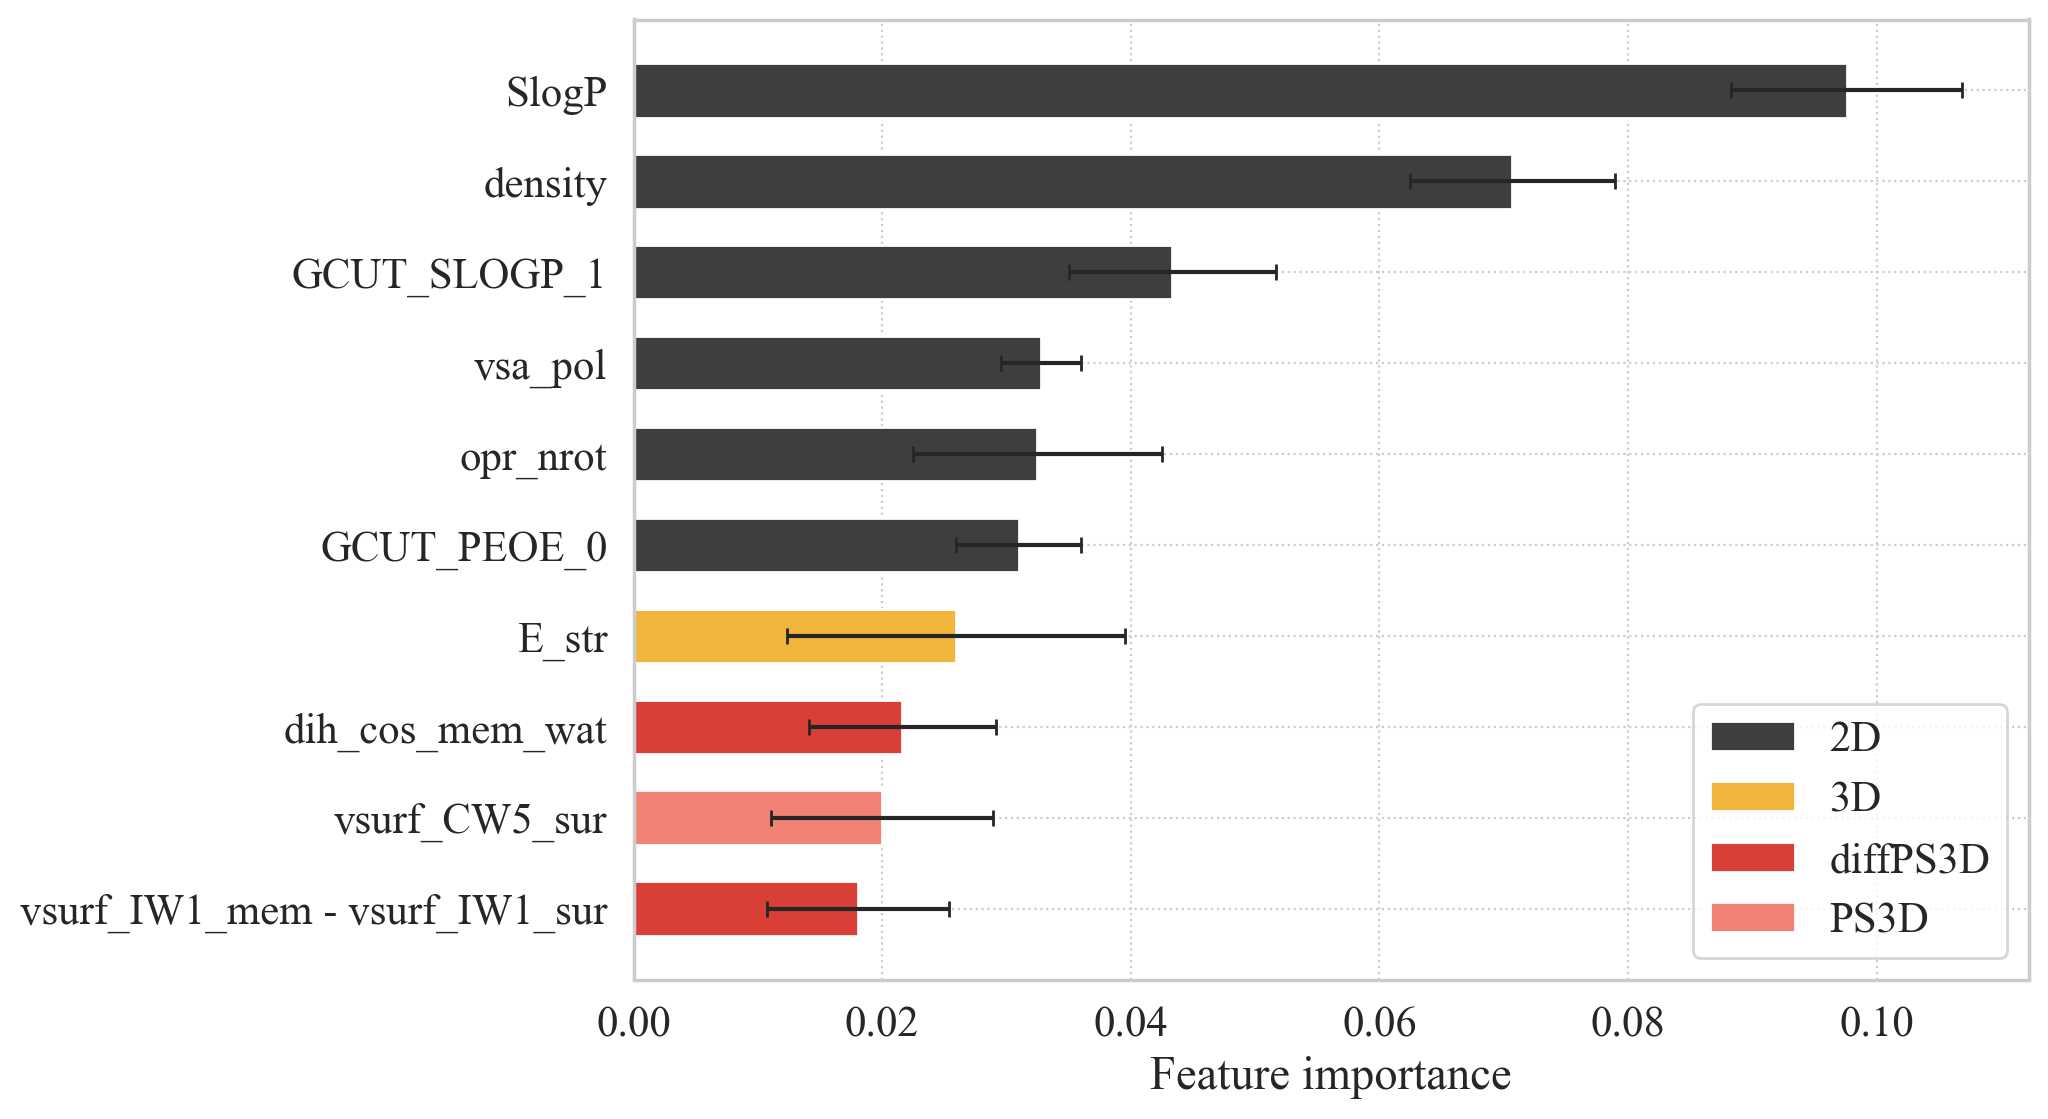

In [17]:
feature_importances.head(15)

# plot
_ = 10
import importlib
importlib.reload(plot_functions)

plot_functions.plot_barh([list(range(_))], [feature_importances['mean'].to_list()[:_][::-1]],
                         [['2D','','','','','','3D','diffPS3D','PS3D',''][::-1]],
                         [[COLOR_DICT[_] for _ in feature_importances['type'].to_list()[:_][::-1]]],
                         xerr=[feature_importances['std'].to_list()[:_][::-1]],
                         title=None, x_name='Feature importance', y_name=None,
                         y_ticks=[list(range(_)), feature_importances['Unnamed: 0'].to_list()[:_][::-1]],
                         grid=True, spines=True,
                         legend=True, legend_outside=False)

### Calculate validation metrics for each dataset.

In [21]:
# OPTIMIZE
best_model = 'XGBoost'

pred = pd.read_csv(f'predicted/validation/{best_model}_predicted.csv', index_col=0)
exps = pred['exp'].to_numpy()
preds = pred['pred'].to_numpy()

set_name = ['2016_Furukawa', '2020_Furukawa', '2021_Kelly', '2022_Bhardwaj']

for now_set in set_name:
    exp = exps[df[df['Set']==now_set].index.to_list()]
    pred = preds[df[df['Set']==now_set].index.to_list()]
    MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(exp, pred, round_num=2)
    print(f'{now_set:13}: R={R:.2f}, MAE={MAE:.2f}, RMSE={RMSE:.2f}, R2={R2:.2f}')

2016_Furukawa: R=0.86, MAE=0.41, RMSE=0.51, R2=0.71
2020_Furukawa: R=0.45, MAE=0.54, RMSE=0.66, R2=0.17
2021_Kelly   : R=0.83, MAE=0.31, RMSE=0.40, R2=0.69
2022_Bhardwaj: R=0.70, MAE=0.65, RMSE=0.85, R2=0.47


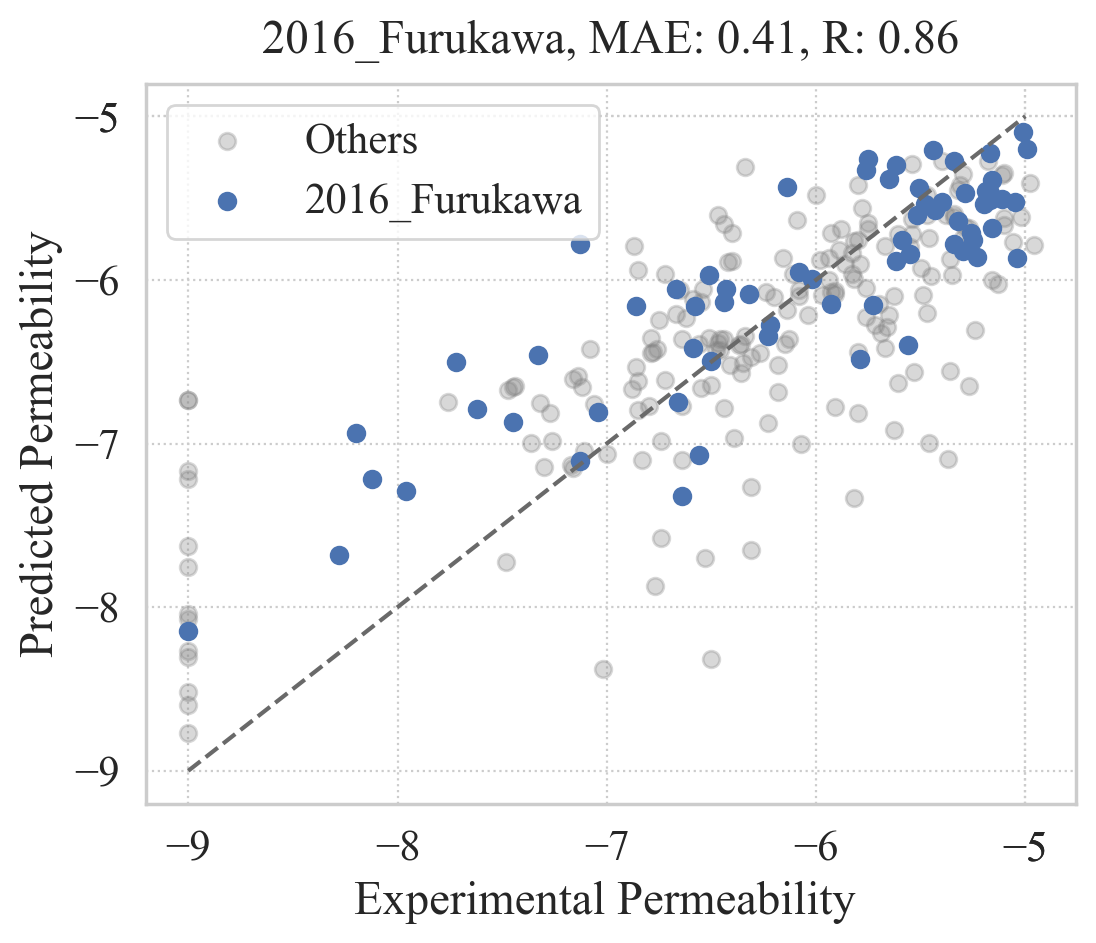

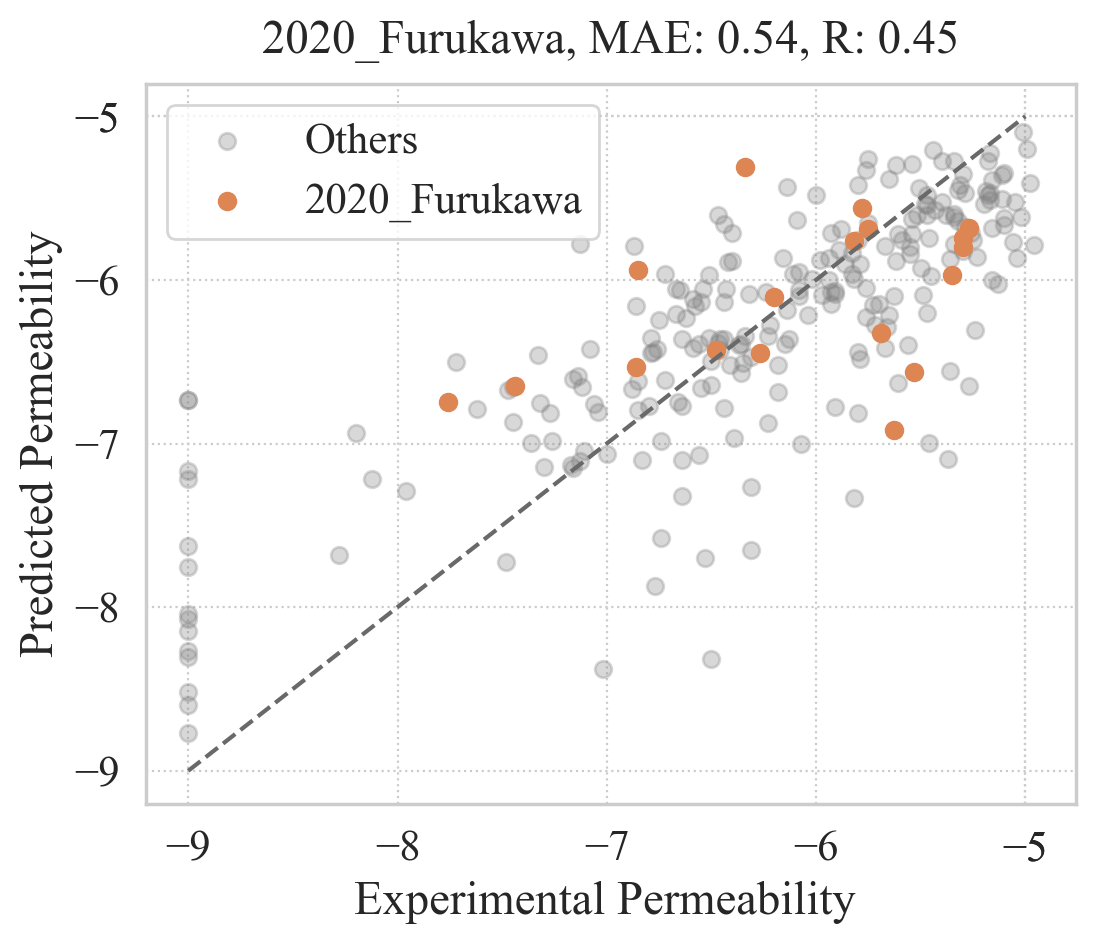

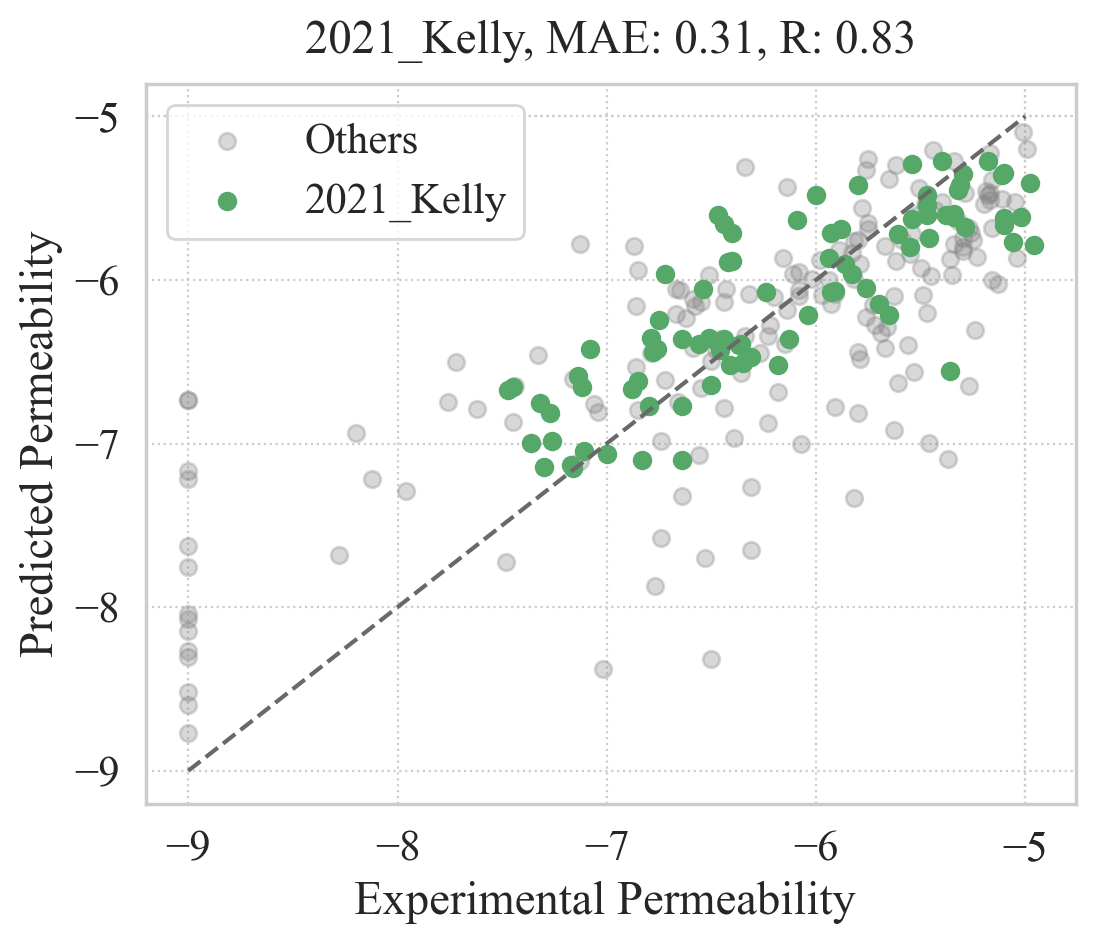

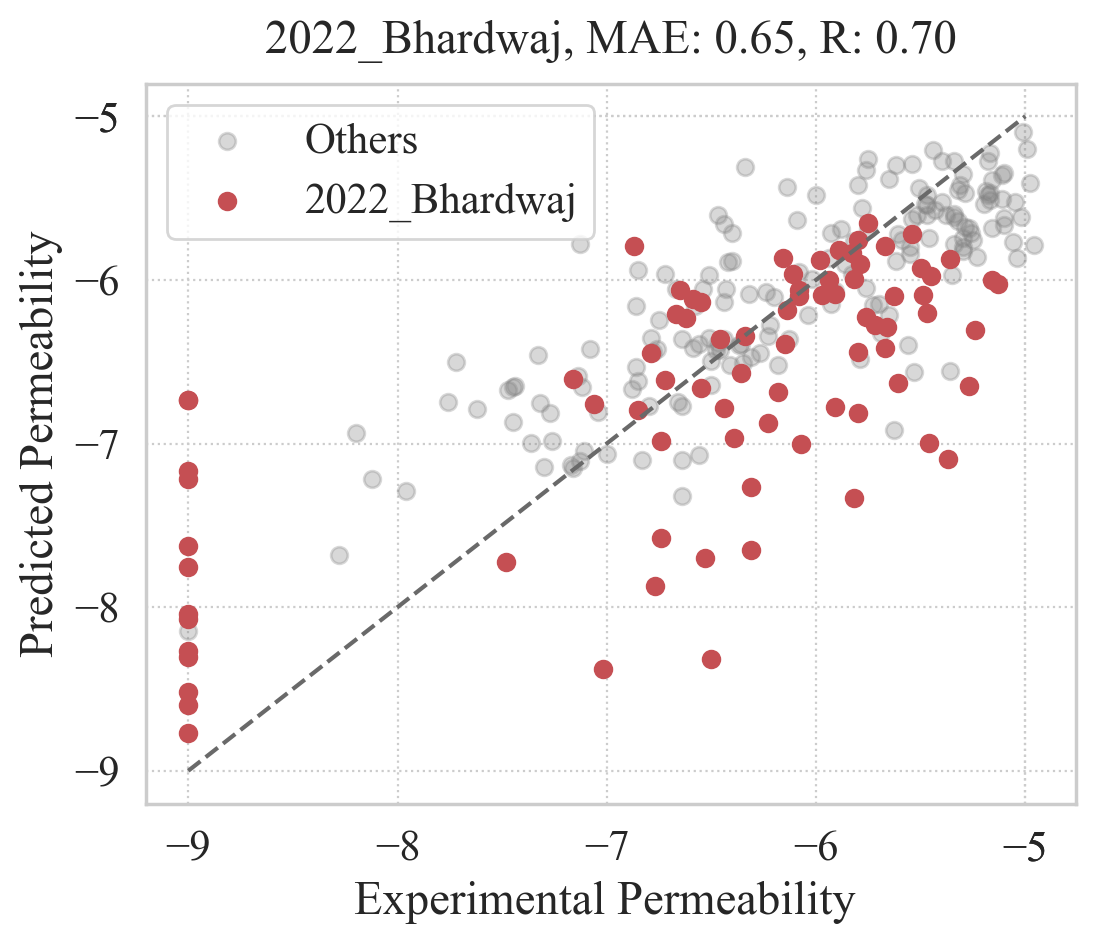

In [22]:
for now_set in set_name:
    mae = mean_absolute_error(exps[df[df['Set']==now_set].index.to_list()], preds[df[df['Set']==now_set].index.to_list()])
    r = pearsonr(exps[df[df['Set']==now_set].index.to_list()], preds[df[df['Set']==now_set].index.to_list()])[0]
    title = f"{now_set}, MAE: {mae:.2f}, R: {r:.2f}"
    color = COLOR_DICT[now_set]

    plot_functions.plot_scatter([exps[df[df['Set']!=now_set].index.to_list()], exps[df[df['Set']==now_set].index.to_list()]],
                                [preds[df[df['Set']!=now_set].index.to_list()], preds[df[df['Set']==now_set].index.to_list()]],
                                ['Others', now_set], 'Experimental Permeability ', 'Predicted Permeability',
                                title=title,
                                x_ticks=[-9, -8, -7, -6, -5, -5],
                                y_ticks=[-9, -8, -7, -6, -5, -5],
                                color_list=['gray', color],
                                alpha_list=[0.3, 1],
                                # s=26,
                                legend=True, legend_outside=False,
                                diagonal=True,
                                )

### Ablation Study
+ Perform validation using descriptors obtained from combinations of 2D, 3D, PS3D, and diffPS3D to evaluate prediction accuracy.

In [6]:
th = 0.6

use_features = pd.read_csv(f'data/use_features_th{th}.csv')

feature_type = ['2D', '3D', 'PS3D', 'diffPS3D']
feature_name_ = {}
feature_name_['2D'] = pd.read_excel('data/2D.xlsx', index_col=0).columns.to_list()
feature_name_['3D'] = pd.read_excel('data/nonPS3D.xlsx', index_col=0).columns.to_list()
feature_name_['PS3D'] = pd.read_excel('data/PS3D.xlsx', index_col=0).columns.to_list()
feature_name_['diffPS3D'] = pd.read_excel('data/diffPS3D.xlsx', index_col=0).columns.to_list()

for type in feature_type:
    print(f"{type}: {len(use_features[use_features['feature'].isin(feature_name_[type])])}")

2D: 20
3D: 1
PS3D: 28
diffPS3D: 45


In [22]:
# OPTIMIZE
name = 'XGBoost'

df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]
model = training_utils.create_model(name, is_search=False, best_params=best_params)
os.makedirs('predicted/ablation', exist_ok=True)

combinations_list = []
for r in range(1, len(feature_type) + 1):
    combinations_list.extend(['_'.join(comb) for comb in itertools.combinations(['A', 'B', 'C', 'D'], r)])


for now_comb in tqdm(combinations_list[::-1]):
    use_features_now = []
    if 'A' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['2D'])]['feature'].to_list())
    if 'B' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['3D'])]['feature'].to_list())
    if 'C' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['PS3D'])]['feature'].to_list())
    if 'D' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['diffPS3D'])]['feature'].to_list())

    X_now = X[use_features_now]

    metrics, index, exps, preds, _ = [], [], [], [], []
    for i in range(cv):
        model.fit(X_now.iloc[train_index_cv[i]].to_numpy(), y[train_index_cv[i]])
        y_pred = model.predict(X_now.iloc[test_index_cv[i]].to_numpy())
        MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(y[test_index_cv[i]], y_pred, round_num=5)
        metrics.append([MAE, RMSE, R, MSE, R2])
        index.extend(test_index_cv[i].tolist())
        exps.extend(y[test_index_cv[i]].tolist())
        preds.extend(y_pred.tolist())
        _.extend([i]*len(test_index_cv[i]))

    metrics = pd.DataFrame(metrics, columns=['MAE', 'RMSE', 'R', 'MSE', 'R2']).T
    metrics['mean'] = metrics.mean(axis=1)
    metrics['std'] = metrics.std(axis=1)
    metrics.to_csv(f'predicted/ablation/{now_comb}_metrics.csv')

    pred = pd.DataFrame({'exp': exps, 'pred': preds, 'cv': _}, index=index).sort_index()
    pred.to_csv(f'predicted/ablation/{now_comb}_predicted.csv')


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [02:10<00:00,  8.69s/it]


In [23]:
for now_comb in combinations_list[::-1]:
    use_features_now = []
    if 'A' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['2D'])]['feature'].to_list())
    if 'B' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['3D'])]['feature'].to_list())
    if 'C' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['PS3D'])]['feature'].to_list())
    if 'D' in now_comb:
        use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['diffPS3D'])]['feature'].to_list())

    print(f'{now_comb:7}: {len(use_features_now):2}', end=', ')

    metrics = pd.read_csv(f'predicted/ablation/{now_comb}_metrics.csv', index_col=0).T

    for _ in ['R', 'MAE', 'RMSE', 'R2']:
        print(f"{metrics[_].loc['mean']:0.2f} ± {metrics[_].loc['std']:0.2f}", end=', ')
    print()

A_B_C_D: 94, 0.77 ± 0.06, 0.46 ± 0.05, 0.62 ± 0.06, 0.58 ± 0.08, 
B_C_D  : 74, 0.57 ± 0.11, 0.61 ± 0.08, 0.80 ± 0.11, 0.29 ± 0.14, 
A_C_D  : 93, 0.78 ± 0.06, 0.46 ± 0.05, 0.61 ± 0.07, 0.58 ± 0.08, 
A_B_D  : 66, 0.75 ± 0.08, 0.48 ± 0.05, 0.64 ± 0.07, 0.54 ± 0.10, 
A_B_C  : 49, 0.79 ± 0.05, 0.44 ± 0.05, 0.59 ± 0.08, 0.61 ± 0.07, 
C_D    : 73, 0.51 ± 0.12, 0.63 ± 0.08, 0.84 ± 0.11, 0.23 ± 0.16, 
B_D    : 46, 0.35 ± 0.11, 0.72 ± 0.07, 0.92 ± 0.08, 0.07 ± 0.14, 
B_C    : 29, 0.60 ± 0.11, 0.60 ± 0.08, 0.78 ± 0.12, 0.33 ± 0.16, 
A_D    : 65, 0.75 ± 0.08, 0.48 ± 0.05, 0.64 ± 0.08, 0.55 ± 0.11, 
A_C    : 48, 0.79 ± 0.05, 0.44 ± 0.05, 0.60 ± 0.08, 0.61 ± 0.08, 
A_B    : 21, 0.75 ± 0.03, 0.49 ± 0.03, 0.65 ± 0.06, 0.53 ± 0.03, 
D      : 45, 0.23 ± 0.14, 0.76 ± 0.06, 0.97 ± 0.07, -0.04 ± 0.16, 
C      : 28, 0.57 ± 0.15, 0.61 ± 0.09, 0.80 ± 0.14, 0.28 ± 0.21, 
B      :  1, 0.25 ± 0.11, 0.83 ± 0.08, 1.15 ± 0.10, -0.55 ± 0.50, 
A      : 20, 0.77 ± 0.04, 0.46 ± 0.04, 0.63 ± 0.06, 0.56 ± 0.04, 


### Verification of prediction accuracy when treating individual datasets as test data. 
+ Error bars calculated using the bootstrap method.

In [7]:
th = 0.6
use_features = pd.read_csv(f'data/use_features_th{th}.csv')

feature_type = ['2D', '3D', 'PS3D', 'diffPS3D']
feature_name_ = {}
feature_name_['2D'] = pd.read_excel('data/2D.xlsx', index_col=0).columns.to_list()
feature_name_['3D'] = pd.read_excel('data/nonPS3D.xlsx', index_col=0).columns.to_list()
feature_name_['PS3D'] = pd.read_excel('data/PS3D.xlsx', index_col=0).columns.to_list()
feature_name_['diffPS3D'] = pd.read_excel('data/diffPS3D.xlsx', index_col=0).columns.to_list()

set_name = ['2016_Furukawa', '2020_Furukawa', '2021_Kelly', '2022_Bhardwaj']

combinations_list = []
for r in range(1, len(feature_type) + 1):
    combinations_list.extend(['_'.join(comb) for comb in itertools.combinations(['A', 'B', 'C', 'D'], r)])

In [20]:
#def bootstrap_ci_metrics(y_true, y_pred, n_boot=1000, alpha=0.05):
    
#    """
#    Confidence interval calculation by bootstrapping

#    Parameters
#    ----------
#    y_true: numpy array
#        experimental data
#    y_pred: numpy array
#        predicted data
#    n_boot: int
#        Number of Bootstrap Iterations
#    alpha: float        
#        Significance level (0.05 → 95% CI)

#    Return:
#    ----------
#      lower (5-Dimensional Array): Lower threshold (2.5%) for MAE, RMSE, R, MSE, R2
#      upper (5-Dimensional Array): Upper threshold (2.5%) for MAE, RMSE, R, MSE, R2
#    """
#    n = len(y_true)
#    boot_metrics = np.zeros((n_boot, 5))
#
#    for b in range(n_boot):
#        idx = np.random.randint(0, n, size=n)  # テストデータのインデックスを復元抽出
#        yt_b = y_true[idx]
#        yp_b = y_pred[idx]
#
#        MAE_b, RMSE_b, R_b, MSE_b, R2_b = training_utils.evaluate_model(
#            yt_b, yp_b, round_num=5
#        )
#        boot_metrics[b, :] = [MAE_b, RMSE_b, R_b, MSE_b, R2_b]

#    lower = np.percentile(boot_metrics, 100 * (alpha / 2), axis=0)
#    upper = np.percentile(boot_metrics, 100 * (1 - alpha / 2), axis=0)

#    return lower, upper

In [19]:
def bootstrap_mean_sd_metrics(y_true, y_pred, n_boot=1000):
    """
    Estimate standard deviations by Bootstraping

    Parameters
    ----------
    y_true: numpy array
        experimental data
    y_pred: numpy array
        predicted data
    n_boot: int
        Number of Bootstrap Iterations


    Returns
    -------
      mean_vals: [MAE_mean, RMSE_mean, R_mean, MSE_mean, R2_mean]
      sd_vals:   [MAE_sd,   RMSE_sd,   R_sd,   MSE_sd,   R2_sd]
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    boot_metrics = np.zeros((n_boot, 5))

    for b in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        yt_b = y_true[idx]
        yp_b = y_pred[idx]

        MAE_b, RMSE_b, R_b, MSE_b, R2_b = training_utils.evaluate_model(
            yt_b, yp_b, round_num=5
        )
        boot_metrics[b, :] = [MAE_b, RMSE_b, R_b, MSE_b, R2_b]

    mean_vals = boot_metrics.mean(axis=0)
    sd_vals   = boot_metrics.std(axis=0, ddof=1)  # 標本標準偏差

    return mean_vals, sd_vals

In [9]:
name = 'XGBoost'

df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]
model = training_utils.create_model(name, is_search=False, best_params=best_params)
os.makedirs('predicted/test_1', exist_ok=True)

for now_set in set_name:
    X_train = X[df['Set']!=now_set]
    y_train = y[df['Set']!=now_set]
    X_test  = X[df['Set']==now_set]
    y_test  = y[df['Set']==now_set]
    test_index  = df.index[df['Set'] == now_set].tolist()
    
    metrics = []

    for now_comb in tqdm(combinations_list[::-1]):
        use_features_now = []
        if 'A' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['2D'])]['feature'].to_list())
        if 'B' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['3D'])]['feature'].to_list())
        if 'C' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['PS3D'])]['feature'].to_list())
        if 'D' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['diffPS3D'])]['feature'].to_list())


        X_train_now = X_train[use_features_now]
        X_test_now  = X_test[use_features_now]

        #fit
        model.fit(X_train_now, y_train)
        y_pred = model.predict(X_test_now)
        MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(y_test, y_pred, round_num=5)


        pred = pd.DataFrame({'exp': y_test, 'pred': y_pred})
        pred.to_csv(f'predicted/test_1/{now_set}_{now_comb}_pred.csv')

        
        #get standard deviations
        mean_vals, sd_vals = bootstrap_mean_sd_metrics(y_test, y_pred, n_boot=1000)
        MAE_mean_b, RMSE_mean_b, R_mean_b, MSE_mean_b, R2_mean_b = mean_vals
        MAE_sd,     RMSE_sd,     R_sd,     MSE_sd,     R2_sd     = sd_vals        

    
        
        metrics.append([
            MAE, MAE_sd,
            RMSE, RMSE_sd,
            R, R_sd,
            MSE, MSE_sd,
            R2, R2_sd
        ])

#        #get Confidence interval
#        lower, upper = bootstrap_ci_metrics(y_test, y_pred, n_boot=1000, alpha=0.05)
#        (MAE_l, RMSE_l, R_l, MSE_l, R2_l) = lower
#        (MAE_u, RMSE_u, R_u, MSE_u, R2_u) = upper        

#        metrics.append([
#            MAE, MAE_l, MAE_u,
#            RMSE, RMSE_l, RMSE_u,
#            R, R_l, R_u,
#            MSE, MSE_l, MSE_u,
#            R2, R2_l, R2_u
#        ])        


    #output data with standard deviation    
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            'MAE',  'MAE_sd',
            'RMSE', 'RMSE_sd',
            'R',    'R_sd',
            'MSE',  'MSE_sd',
            'R2',   'R2_sd'
        ],
        index=combinations_list[::-1]
    )

    metrics_df.to_csv(f'predicted/test_1/{now_set}_metrics_mean_sd.csv')        

#    #output data with confidence interval
#    metrics_df = pd.DataFrame(
#        metrics,
#        columns=[
#            'MAE',  'MAE_low',  'MAE_high',
#            'RMSE', 'RMSE_low', 'RMSE_high',
#            'R',    'R_low',    'R_high',
#            'MSE',  'MSE_low',  'MSE_high',
#            'R2',   'R2_low',   'R2_high'
#        ],
#        index=combinations_list[::-1]
#    )

#    metrics_df.to_csv(f'predicted/test_{now_set}_metrics_with_bootstrap_ci.csv')        



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:35<00:00,  2.39s/it]


### Shap analysis for when treating individual datasets as test data.

In [30]:
# OPTIMIZE
name = 'XGBoost'

df_search_results = pd.read_csv(f'weight/{name}_search_results.csv')
best_params = df_search_results.iloc[df_search_results['MAE'].idxmin()]
model = training_utils.create_model(name, is_search=False, best_params=best_params)
os.makedirs('predicted/test_1', exist_ok=True)

for now_set in set_name:
    X_train = X[df['Set']!=now_set]
    y_train = y[df['Set']!=now_set]
    X_test  = X[df['Set']==now_set]
    y_test  = y[df['Set']==now_set]
    test_index  = df.index[df['Set'] == now_set].tolist()
    
    metrics = []

    for now_comb in tqdm(combinations_list[::-1]):
        use_features_now = []
        if 'A' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['2D'])]['feature'].to_list())
        if 'B' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['3D'])]['feature'].to_list())
        if 'C' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['PS3D'])]['feature'].to_list())
        if 'D' in now_comb:
            use_features_now.extend(use_features[use_features['feature'].isin(feature_name_['diffPS3D'])]['feature'].to_list())


        X_train_now = X_train[use_features_now]
        X_test_now  = X_test[use_features_now]

        
        # OPTIMIZE
        model.fit(X_train_now, y_train)
        y_pred = model.predict(X_test_now)
        #MAE, RMSE, R, MSE, R2 = training_utils.evaluate_model(y_test, y_pred, round_num=5)

        feature_importances=list(model.feature_importances_)
        fi_df = pd.DataFrame({
            'feature': use_features_now,
            'importance': feature_importances,
        }).sort_values('importance', ascending=False)
        # feature_importances = feature_importances.sort_values('mean', ascending=False)
        fi_df.to_csv(f'predicted/test_1/{now_set}_{now_comb}_feature_importances.csv')

        
        #shap analysis
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_now)
        shap_values_df = pd.DataFrame(
            shap_values,
            columns=X_test_now.columns,
            index=test_index
        )
        shap_values_df.to_csv(
            f'predicted/test_1/{now_set}_{now_comb}_shap_values.csv'
        )
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        shap_importance_df = pd.DataFrame({
            'feature': X_test_now.columns,
            'mean_abs_shap': mean_abs_shap
        }).sort_values('mean_abs_shap', ascending=False)

        shap_importance_df.to_csv(
            f'predicted/test_1/{now_set}_{now_comb}_shap_importance.csv',
            index=False
        )

        top10_features = shap_importance_df['feature'].head(10).tolist()

        #Summary beeswarm plot
        plt.figure()
        shap.summary_plot(
            shap_values,
            X_test_now, 
            show=False,
            max_display=10  # 上位10特徴量のみ表示
        )
        plt.tight_layout()
        plt.savefig(f'predicted/test_1/{now_set}_{now_comb}_shap_summary_top10.png', dpi=300)
        plt.close()
        


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:32<00:00,  2.15s/it]


### Steiger test

In [10]:
def steiger_test_from_corrs(r_xy, r_xz, r_yz, n, two_tailed=True):
    """
    Steiger (1980) test for comparing two dependent correlations
    sharing one variable (overlapping correlations).
    
    Parameters
    ----------
    r_xy : float
        Correlation between x and y
    r_xz : float
        Correlation between x and z
    r_yz : float
        Correlation between y and z
    n : int
        Sample size
    two_tailed : bool, default True
        If True, perform a two-tailed test; otherwise one-tailed.

    Returns
    -------
    t_value : float
        Test statistic (t value)
    p_value : float
        Corresponding p-value
    """

    # Difference between the two correlations
    d = r_xy - r_xz

    # Determinant-like term used by Steiger (1980)
    determin = 1 - r_xy**2 - r_xz**2 - r_yz**2 + 2 * r_xy * r_xz * r_yz

    # Average of the two correlations
    av = (r_xy + r_xz) / 2.0

    # (1 - r_yz)^3 term
    cube = (1 - r_yz)**3

    # Numerator and denominator of the t statistic
    t_num = d * np.sqrt((n - 1) * (1 + r_yz))
    t_den = np.sqrt((2 * (n - 1) / (n - 3)) * determin + av**2 * cube)

    # Final t statistic
    t_value = t_num / t_den

    # Degrees of freedom
    df = n - 2

    # Compute p-value
    p_value = 1 - t.cdf(np.abs(t_value), df)
    if two_tailed:
        p_value *= 2

    return t_value, p_value


In [11]:
def steiger_test_from_data(x, y, z, two_tailed=True):
    """
    Perform Steiger's test directly from raw data vectors x, y, z.
    
    Parameters
    ----------
    x, y, z : array-like
        Input variables of equal length (list, numpy array, or pandas Series)
    two_tailed : bool, default True
        If True, perform a two-tailed test.

    Returns
    -------
    results : dict
        Dictionary containing:
        {
            'r_xy': correlation(x, y),
            'r_xz': correlation(x, z),
            'r_yz': correlation(y, z),
            'n'   : sample size,
            't'   : t statistic,
            'p'   : p-value
        }
    """

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    # All vectors must have the same length
    if not (len(x) == len(y) == len(z)):
        raise ValueError("Input vectors x, y, z must have equal length.")

    n = len(x)

    # Compute correlation matrix
    corr = np.corrcoef(np.vstack([x, y, z]))
    r_xy = corr[0, 1]
    r_xz = corr[0, 2]
    r_yz = corr[1, 2]

    # Re-use the correlation-based Steiger test
    t_value, p_value = steiger_test_from_corrs(r_xy, r_xz, r_yz, n, two_tailed=two_tailed)

    return {
        'r_xy': r_xy,
        'r_xz': r_xz,
        'r_yz': r_yz,
        'n': n,
        't': t_value,
        'p': p_value,
    }


In [12]:
set_name = ['2016_Furukawa', '2020_Furukawa', '2021_Kelly', '2022_Bhardwaj']
#A,B,C,D, = 2D, 3D, PS3D, diffPS3D

#combinations_list = []
#for r in range(1, len(feature_type) + 1):
#    combinations_list.extend(['_'.join(comb) for comb in itertools.combinations(['A', 'B', 'C', 'D'], r)])

combinations_list=['A','C','A_C','A_B_C_D']
n_comb = len(combinations_list)
p_mat = pd.DataFrame(
        np.nan,
        index=combinations_list,
        columns=combinations_list
)

for now_set in set_name:
    X_train = X[df['Set']!=now_set]
    y_train = y[df['Set']!=now_set]
    X_test  = X[df['Set']==now_set]
    y_test  = y[df['Set']==now_set]

    
    metrics = []

    for i, now_comb in enumerate(combinations_list):
        for j, now_comb2 in enumerate(combinations_list):

            if i == j:
                p_mat.iloc[i, j] = 1.0
                continue

            if j < i:
                continue
            
            data1 = pd.read_csv(f'predicted/test_1/{now_set}_{now_comb}_pred.csv')
            data2 = pd.read_csv(f'predicted/test_1/{now_set}_{now_comb2}_pred.csv')
            res = steiger_test_from_data(data2['exp'],data1['pred'], data2['pred'])

            p_mat.loc[now_comb, now_comb2] = res['p']
    p_mat.to_csv(f'predicted/test_1/{now_set}_steiger_pmatrix.csv',float_format="%.3f")            


In [16]:
# For checking data
now_set='2020_Furukawa'
comb1='A'
comb2='A_C'



data1 = pd.read_csv(f'predicted/ablation/{comb1}_predicted.csv')
data2 = pd.read_csv(f'predicted/ablation/{comb2}_predicted.csv')
res = steiger_test_from_data(data2['exp'],data1['pred'], data2['pred'])

#data1 = pd.read_csv(f'predicted/test_1/{now_set}_{comb1}_pred.csv')
#data2 = pd.read_csv(f'predicted/test_1/{now_set}_{comb2}_pred.csv')
#res = steiger_test_from_data(data2['exp'],data1['pred'], data2['pred'])


print(f"r_xy = {res['r_xy']:.3f}")
print(f"r_xz = {res['r_xz']:.3f}")
print(f"r_yz = {res['r_yz']:.3f}")
print(f"n    = {res['n']}")
print(f"t    = {res['t']:.3f}")
print(f"p    = {res['p']:.4f}")

r_xy = 0.761
r_xz = 0.783
r_yz = 0.934
n    = 252
t    = -1.556
p    = 0.1209
